# The Austrian Grand Prix - 2026 🇦🇹 | The Qualifying

- This notebook is full pre-race technical debrief of the Qualifying Session at the Austrian Grandprix, 2026.
- I have tried to work with the data the best I can considering the limitations that I have faced, most significantly not having access to the telemetry of the cars (will be fixed in the near future).
- Hence, I have researched technical regulations for hard limits while making resonable assumptions where possible to navigate the problems.

## Necessary Imports

In [1]:
# FastF1 Deps
import fastf1
from fastf1.core import Laps

# Data Deps
import pandas as pd

# Visualisation Deps
import matplotlib.pyplot as plt

# Core Deps
from pathlib import Path
import sys
sys.path.append(str(Path("../../")))

# Source Deps
from mark_1 import DataLoader, DataPipeline, DataVisualisation
from mark_1.utils import display_sector_stat

## Notebook-Level Setup and Configurations

In [2]:
# Accessing the Current Working Directory for Absolute Root Path
REPO_ROOT_PATH = Path.cwd().parent.parent.parent

# Pathlib Path Objects for the Notebook
F1_PATH = REPO_ROOT_PATH / "F1"
CACHE_PATH = F1_PATH / "cache"
CACHE_PATH.mkdir(exist_ok=True)

# Path to store the final quali frame
f1_data_path = F1_PATH / "data"
f1_data_path.mkdir(exist_ok=True)

# Adding the source scripts into the Python Execution Path
if F1_PATH not in sys.path:
    sys.path.append(str(F1_PATH))

## Loading the Event

In [3]:
# Defaulting the Requests for Caching to a Predefined path
# fastf1.Cache.clear_cache(cache_dir=str(CACHE_PATH))
fastf1.Cache.enable_cache(cache_dir=str(CACHE_PATH))

# Enabling Offline Mode
fastf1.Cache.offline_mode(enabled=True)

# The GP Event
austria_2026 = fastf1.get_event(
    year=2026,
    gp="austria"
)
print(austria_2026)

RoundNumber                                                  8
Country                                                Austria
Location                                             Spielberg
OfficialEventName    FORMULA 1 LENOVO AUSTRIAN GRAND PRIX 2026
EventDate                                  2026-06-28 00:00:00
EventName                                  Austrian Grand Prix
EventFormat                                       conventional
Session1                                            Practice 1
Session1Date                         2026-06-26 13:30:00+02:00
Session1DateUtc                            2026-06-26 11:30:00
Session2                                            Practice 2
Session2Date                         2026-06-26 17:00:00+02:00
Session2DateUtc                            2026-06-26 15:00:00
Session3                                            Practice 3
Session3Date                         2026-06-27 12:30:00+02:00
Session3DateUtc                            2026-06-27 1

In [4]:
austria_2026 = DataLoader(race_event=austria_2026)
gp_weekend = austria_2026.load_data()

core           INFO 	Loading data for Austrian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '16', '44', '12', '3', '1', '81', '6', '30', '41', '10', '5', '87', '27', '31', '43', '55', '23', '11', '77', '14', '18']
core           INFO 	Loading data for Austrian Grand Prix - Race [v3.8.3]
req            INFO 	U

In [5]:
# Decompiling the Session Data
quali = gp_weekend.quali_session
race = gp_weekend.race_session

## Data Engineering

<img src="../../../assets/circuit_maps/austria_map.avif">

In [6]:
# Instantiating the DataPipeline
data_pipe = DataPipeline(circuit="austria")

# Full Laps Frame
assert quali, "Qualifying was not loaded"
quali_laps_full = quali.laps

# Drop columns
drop_cols = [
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime", 
    "DeletedReason", "FastF1Generated", "IsAccurate", "Time"
]

# Filtered Laps
_, _, q3 = quali_laps_full.split_qualifying_sessions()
assert isinstance(q3, Laps), "Q3 Laps was None"
filtered_quali_laps = q3.drop(drop_cols, axis=1)

# Rounding down to the laps of the top runners
assert race, "Race was not loaded"
top_5_drivers = race.results.iloc[:5]["Abbreviation"].to_list()

# Retrieving the best laps
fastest_quali_laps = data_pipe.get_filtered_quali_laps(
    laps_frame=filtered_quali_laps,
    drivers=top_5_drivers
)

fastest_quali_laps.head()

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,ANT,0 days 00:00:16.477000,0 days 00:00:29.666000,0 days 00:00:19.998000,0 days 00:01:06.414000,319.0,229.0,281.0,321.0
1,HAM,0 days 00:00:16.521000,0 days 00:00:29.690000,0 days 00:00:20.197000,0 days 00:01:06.408000,310.0,221.0,279.0,307.0
2,PIA,0 days 00:00:16.600000,0 days 00:00:29.742000,0 days 00:00:20.133000,0 days 00:01:06.511000,309.0,229.0,277.0,316.0
3,RUS,0 days 00:00:16.424000,0 days 00:00:29.620000,0 days 00:00:20.042000,0 days 00:01:06.113000,316.0,227.0,283.0,323.0
4,VER,0 days 00:00:16.501000,0 days 00:00:29.719000,0 days 00:00:20.255000,0 days 00:01:06.475000,317.0,224.0,275.0,316.0


In [7]:
# Transforming all the timedelta objects
get_seconds = pd.Timedelta.total_seconds

fastest_quali_laps["LapTime"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["LapTime"]),
    axis=1
)
fastest_quali_laps["Sector1Time"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["Sector1Time"]),
    axis=1
)
fastest_quali_laps["Sector2Time"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["Sector2Time"]),
    axis=1
)
fastest_quali_laps["Sector3Time"] = fastest_quali_laps.apply(
    lambda x: get_seconds(x["Sector3Time"]),
    axis=1
)

fastest_quali_laps.head()

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST
0,ANT,16.477,29.666,19.998,66.414,319.0,229.0,281.0,321.0
1,HAM,16.521,29.690,20.197,66.408,310.0,221.0,279.0,307.0
2,PIA,16.600,29.742,20.133,66.511,309.0,229.0,277.0,316.0
3,RUS,16.424,29.620,20.042,66.113,316.0,227.0,283.0,323.0
4,VER,16.501,29.719,20.255,66.475,317.0,224.0,275.0,316.0


### Best Theoritical Time

In [8]:
# Sector Enum
sectors = ["Sector1Time", "Sector2Time", "Sector3Time"]

# The Theoritical Best Time
best_times = {}

print("Theoritical Best Sectors:\n")
for idx, key in enumerate(sectors):
    fastest_sector = fastest_quali_laps.loc[fastest_quali_laps[key].idxmin()]
    best_times[key] = fastest_sector[key]
    
    assert isinstance(fastest_sector, pd.Series), f"Fastest sector was not found for {key}"
    display_sector_stat(fastest_sector, sector=idx+1)

fastest_laptime = (
    best_times["Sector1Time"] 
    + best_times["Sector2Time"] 
    + best_times["Sector3Time"]
)
print(f"Theoretical Best Time: {fastest_laptime}")

Theoritical Best Sectors:

Sector - 1
Driver: RUS
Sector Time: 16.424
Speed I1: 316.0
Longest Straight Speed: 323.0

Sector - 2
Driver: RUS
Sector Time: 29.62
Speed I2: 227.0
Longest Straight Speed: 323.0

Sector - 3
Driver: ANT
Sector Time: 19.998
Speed I3: 281.0
Longest Straight Speed: 321.0

Theoretical Best Time: 66.042


### Aero Efficiency Index
A comparison of the average speed (weighted by sector time) carried by each of the drivers and teams through the lap. The RedBull Ring, has a deceptively simple layout which I feel can be broken as follows:
1. `Rear-Axle | Downforce & Traction` **Sector - 1**: Generically, due to the stop and go nature of the circuit it is evident to always maintain consistent grip throughout the lap to generate the acceleration necessary to reduce laptime. However, sector - 1 also requires a good balance of aero to reach higher top-speeds.
2. `Balanced | Downforce - Drag Tradeoff` **Sector - 2**: Requires sufficient traction for putting the power down through turns 3-4 and accelerating quickly to get a high top speed through the speed trap (before turn - 4). However, it ends through the twisties all of which are medium to high speed corners thereby required front-end bite.
3. `Front-Axle | Downforce & Agility` **Sector - 3**: Requires sufficient downforce to gain speed in the twisties all the way to the end of the lap. This sector thereby is front-axle limited.

In [9]:
# Sector - 1
fastest_quali_laps.loc[:, "RearAEI"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI1"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector1Time"],
        purple_sector_time=fastest_quali_laps["Sector1Time"].min()
    ),
    axis=1
)

# Sector - 2
fastest_quali_laps.loc[:, "BalancedAEI"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedI2"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector2Time"],
        purple_sector_time=fastest_quali_laps["Sector2Time"].min()
    ),
    axis=1
)

# Sector - 3
fastest_quali_laps.loc[:, "FrontAEI"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_aero_efficiency(
        v_sector=x["SpeedFL"], 
        v_st=x["SpeedST"],
        sector_time=x["Sector3Time"],
        purple_sector_time=fastest_quali_laps["Sector3Time"].min()
    ),
    axis=1
)

fastest_quali_laps

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,RearAEI,BalancedAEI,FrontAEI
0,ANT,16.477,29.666,19.998,66.414,319.0,229.0,281.0,321.0,0.275159,0.197858,0.243164
1,HAM,16.521,29.690,20.197,66.408,310.0,221.0,279.0,307.0,0.278845,0.199492,0.249956
2,PIA,16.600,29.742,20.133,66.511,309.0,229.0,277.0,316.0,0.268745,0.200475,0.241862
3,RUS,16.424,29.620,20.042,66.113,316.0,227.0,283.0,323.0,0.271758,0.195218,0.242844
4,VER,16.501,29.719,20.255,66.475,317.0,224.0,275.0,316.0,0.277357,0.196250,0.238670


### Power Unit Performance

In [10]:
# ============================ Adding the Kinetic Energies ============================
# Sector - 1
fastest_quali_laps.loc[:, "KineticEnergyS1_KJ"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# Sector - 2
fastest_quali_laps.loc[:, "KineticEnergyS2_KJ"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedI2"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# Sector - 3
fastest_quali_laps.loc[:, "KineticEnergyS3_KJ"] = fastest_quali_laps.apply(
    lambda x: data_pipe._calc_delta_kinetic_energy(
        v1=x["SpeedFL"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

# ============================ Adding the Power in KW ============================
# Sector - 1
fastest_quali_laps["PowerS1_KW"] = (
    fastest_quali_laps["KineticEnergyS1_KJ"] / 
    fastest_quali_laps["Sector1Time"]
)

# Sector - 2
fastest_quali_laps["PowerS2_KW"] = (
    fastest_quali_laps["KineticEnergyS2_KJ"] / 
    fastest_quali_laps["Sector2Time"]
)

# Sector - 3
fastest_quali_laps["PowerS3_KW"] = (
    fastest_quali_laps["KineticEnergyS3_KJ"] / 
    fastest_quali_laps["Sector3Time"]
)

# ERS Clipping
fastest_quali_laps["ERS_Clipping"] = fastest_quali_laps["SpeedST"] / fastest_quali_laps["SpeedI1"]

# Adding the Acceleration Time
fastest_quali_laps.loc[:, "AccelerationTime"] = fastest_quali_laps.apply(
    lambda x: data_pipe.get_delta_acceleration_time(
        v1=x["SpeedI1"], 
        v2=x["SpeedST"]
    ),
    axis=1
)

fastest_quali_laps

,Driver,Sector1Time,Sector2Time,Sector3Time,LapTime,SpeedI1,SpeedI2,SpeedFL,SpeedST,RearAEI,BalancedAEI,FrontAEI,KineticEnergyS1_KJ,KineticEnergyS2_KJ,KineticEnergyS3_KJ,PowerS1_KW,PowerS2_KW,PowerS3_KW,ERS_Clipping,AccelerationTime
0,ANT,16.477,29.666,19.998,66.414,319.0,229.0,281.0,321.0,0.275159,0.197858,0.243164,38.123457,1507.067901,717.197531,2.313738,50.801183,35.863463,1.006270,9.562500
1,HAM,16.521,29.690,20.197,66.408,310.0,221.0,279.0,307.0,0.278845,0.199492,0.249956,-55.130093,1352.429630,488.695062,-3.336971,45.551688,24.196418,0.990323,9.918963
2,PIA,16.600,29.742,20.133,66.511,309.0,229.0,277.0,316.0,0.268745,0.200475,0.241862,130.304784,1412.206019,688.813426,7.849686,47.481878,34.213154,1.022654,9.792000
3,RUS,16.424,29.620,20.042,66.113,316.0,227.0,283.0,323.0,0.271758,0.195218,0.242844,133.223611,1572.592593,721.962963,8.111520,53.092255,36.022501,1.022152,9.577465
4,VER,16.501,29.719,20.255,66.475,317.0,224.0,275.0,316.0,0.277357,0.196250,0.238670,-18.853241,1479.666667,721.694907,-1.142551,49.788575,35.630457,0.996845,9.668246


## Data Visualisation

In [11]:
# Instantiating the Data Visualisation Handle
assert quali, "The Quali Session wasn't loaded"
data_vis = DataVisualisation(
    session=quali, 
    driver_names=top_5_drivers, 
    circuit="austria"
)

req            INFO 	Using cached data for driver_info


### Aero Efficiency

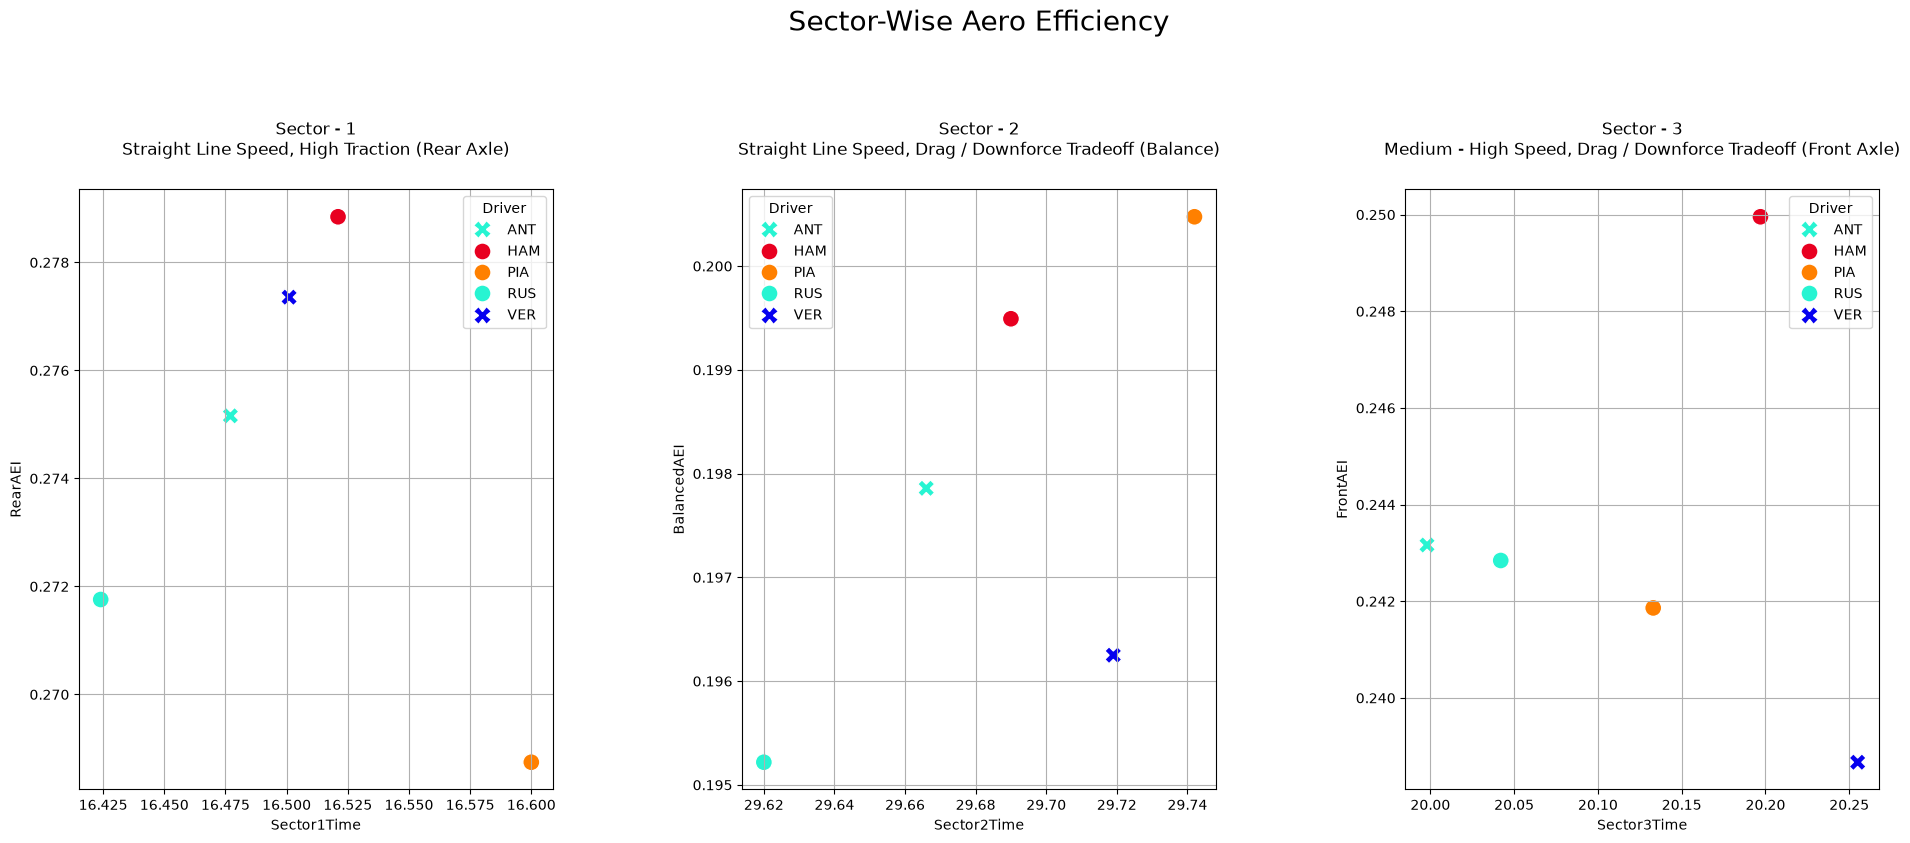

In [12]:
aei_fig = data_vis.create_scatter_plots(
    nrows=1,
    ncols=3,
    figsize=(30, 10),
    data=fastest_quali_laps,
    hue="Driver",
    style="Driver",
    size=150,
    plot_kind="aero"
)

aei_fig.suptitle(
    "Sector-Wise Aero Efficiency",
    fontsize=20
)
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.80, wspace=0.4)
plt.show()

**Important**
- As seen the scatter plots above, the way I have designed the features for Aero Efficiency is dependent on two factors which are:
    - Driver Sector Speed as a ratio of their Top Speed.
    - Driver Sector Time as a ratio of the Purple Sector Time.
- Thus, the above graphs are evidently showcasing this tradeoff as engineered in the setup of teams and driving styles.

**Notable Points**
- Russell has the best times in Sector-1 and Sector-2 which he managed to achieve without maximising to the top-left corner which is the best correlation for this plot.
- This shows that Russell despite lower speed in either sectors in comparison to his top speed (across speed trap) was able to get the fastest times through better traction, and PU usage.
- On the otherhand, Piastri in the top-rigth corner for the same sectors tells the story of higher top speed through the sectors but inconsistencies on PU efficiency and / or traction (stop and go nature of the circuit layout) thereby bleeding laptime eventhough Piastri and Russell have the same PU.
- Lastly, you then Hamilton and Verstappen who are in the middle of this tradeoff due to similar reasons.

### KE and Power Plots

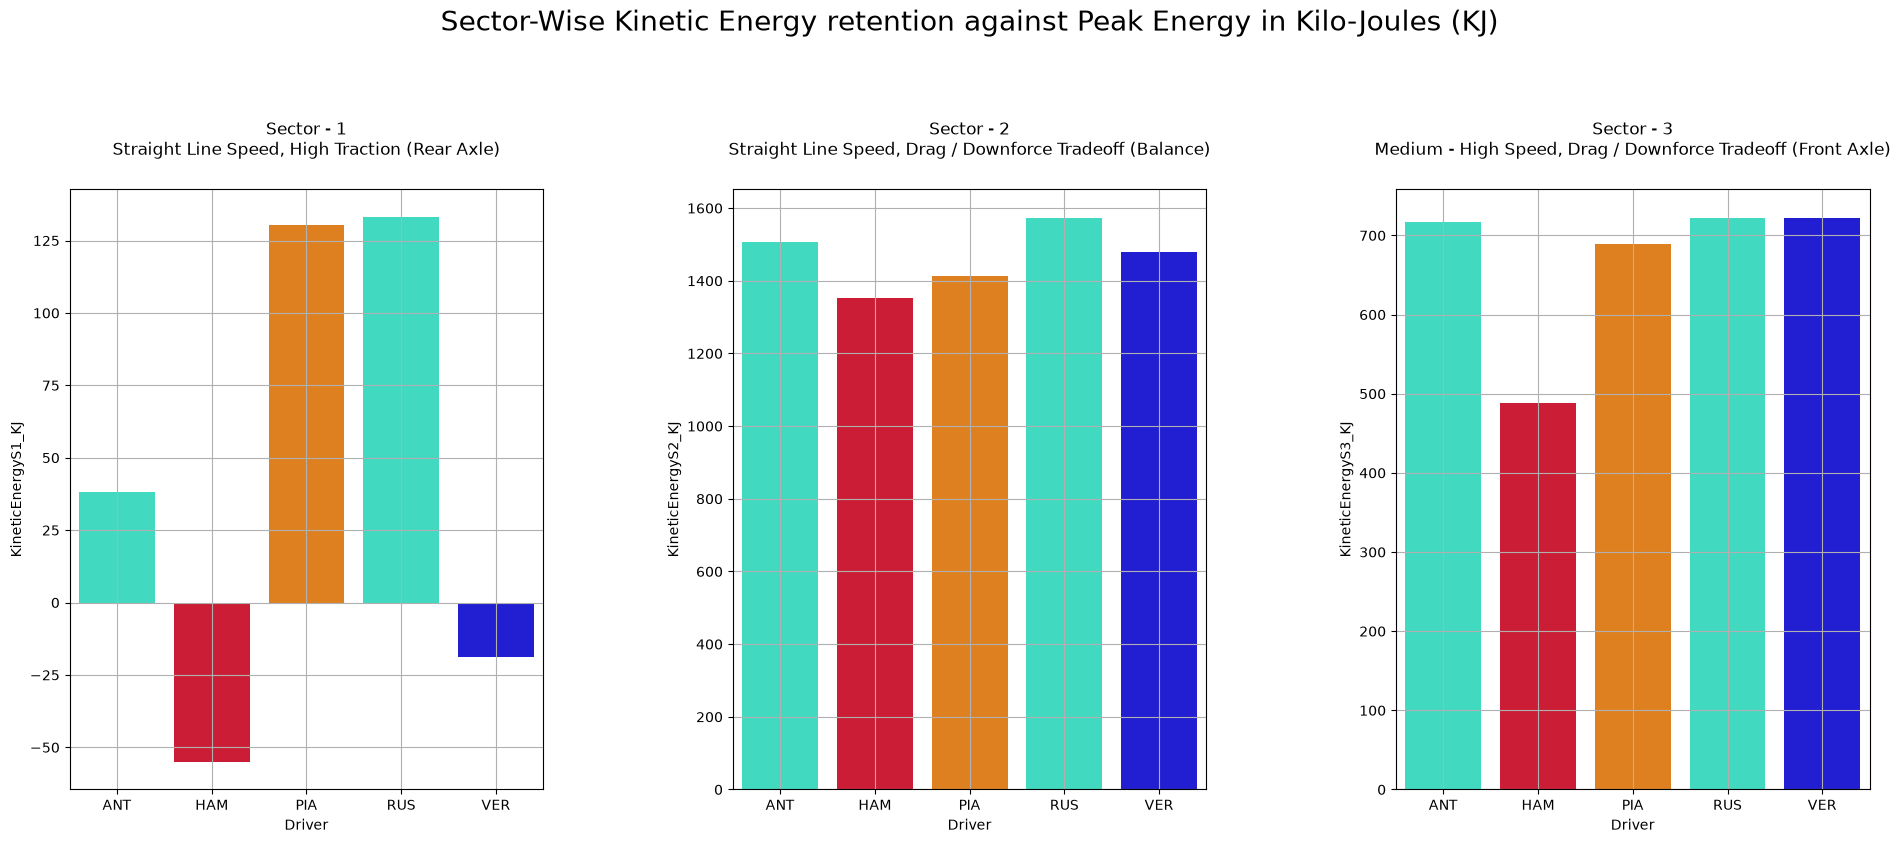

In [13]:
kep_fig = data_vis.create_bar_plots(
    nrows=1, 
    ncols=3,
    figsize=(30, 10),
    data=fastest_quali_laps,
    hue="Driver",
    plot_kind="ke"
)

kep_fig.suptitle(
    "Sector-Wise Kinetic Energy retention against Peak Energy in Kilo-Joules (KJ)",
    fontsize=20
)
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.80, wspace=0.4)
plt.show()

**Important**
- As seen in the bar plots above there is significant difference in trends that needs explanation. The way I have engineered the features for KE retentions suggests the lower KE retention the better (however, this doesn't suggest -ve values to be better).
- This inverse relationship (lower is better) is due to features representing the Delta in KE for each of the sectors wrt each of the drivers respective top speeds. Thus, for every sector the driver maintains lower delta in KE the more time he gains as the PU doesn't need to do extra work to gain speed and remains close to the top band of power.
- However, we can see there a few -ve bars in the plot above. This in indicative of Hamilton and Verstappen having a much higher sector speed (V1) than the absolute top speed at the speed trap (V2). This further explains the usage of the PU for the respective cars as Austria is a Power track with long straights and the current regulations mean energy efficiency is vital. Thus, both drivers have high energy at the start of the lap which is lost dramatically as they go through sectors which require PU efficiency to maintain the power band but they seem to lack and hence have a -ve split for Sector - 1 while the others pan out as expected.
- All of this is verified below in the ERS clipping plot as for Austria, the ERS clip has been taken as the ratio of speed at the end of Sector - 1 and the top speed at the Speed Trap in the middle of Sector - 2. We can see that both Verstappen and Hamilton have $ers\_clipping < 1.0$ ie they are having a higher Speed through Sector - 1 than the Speed Trap.

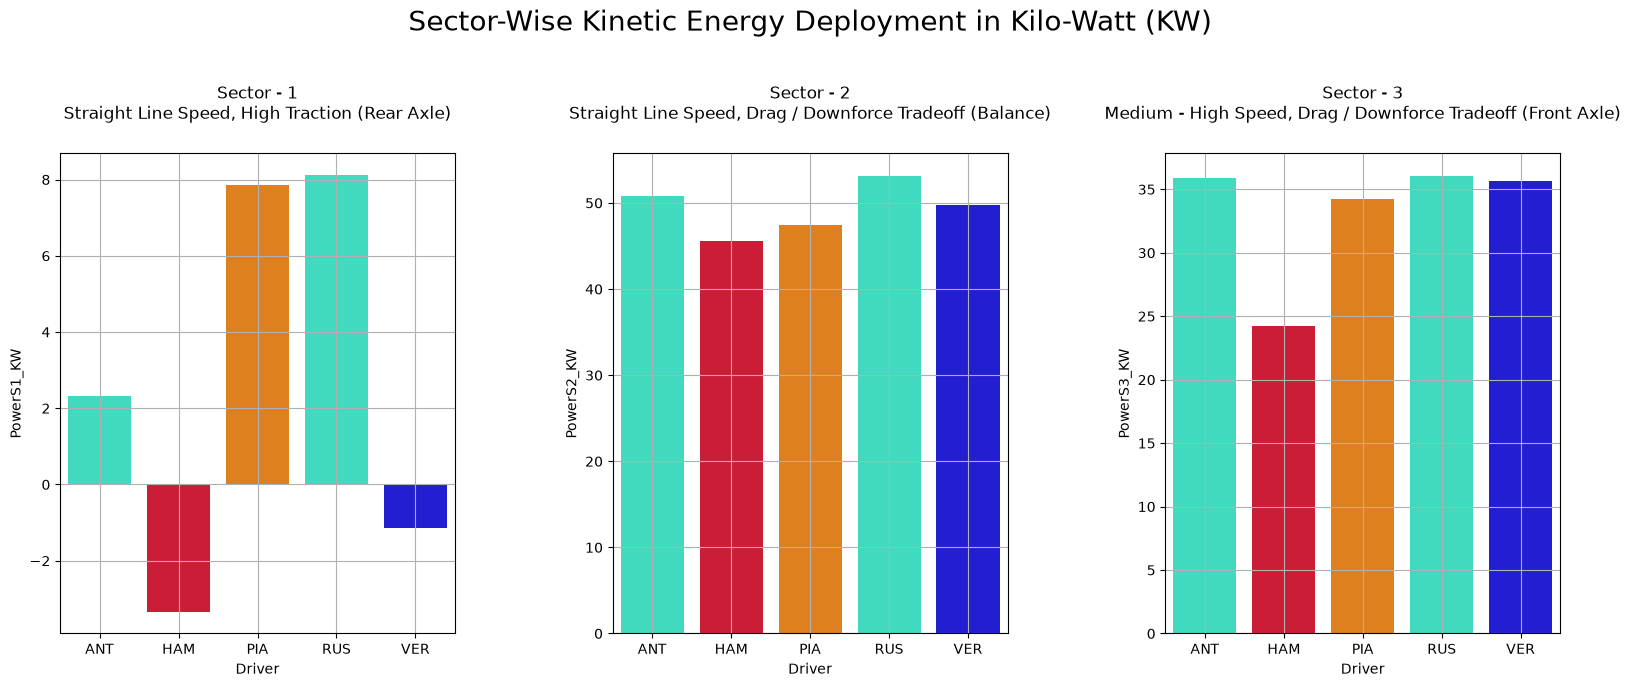

In [14]:
power_fig = data_vis.create_bar_plots(
    nrows=1,
    ncols=3,
    figsize=(25, 8),
    data=fastest_quali_laps,
    hue="Driver",
    plot_kind="power"
)

power_fig.suptitle(
    "Sector-Wise Kinetic Energy Deployment in Kilo-Watt (KW)",
    fontsize=20
)
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.80, wspace=0.4)
plt.show()

### ICE Strength

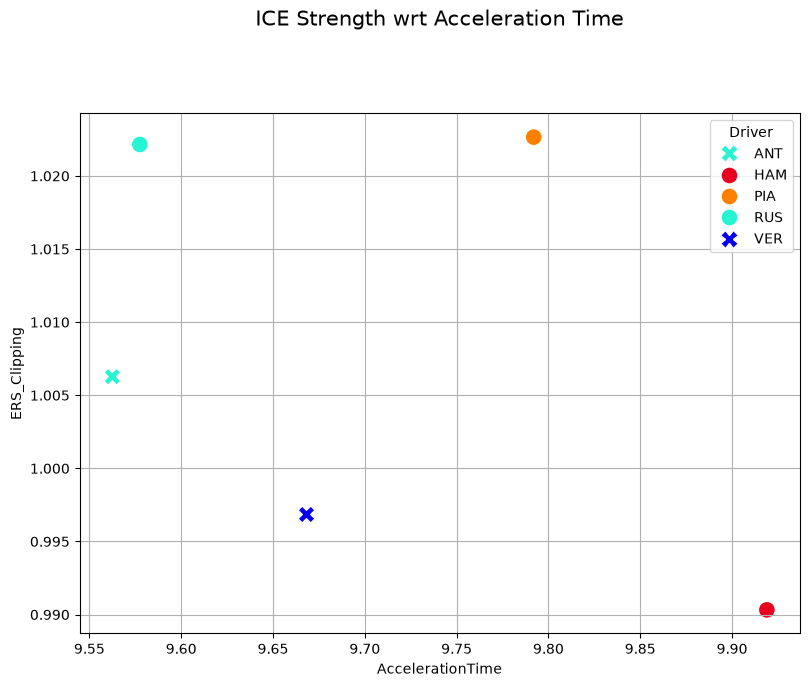

In [15]:
ice_fig = data_vis.create_scatter_plots(
    nrows=1,
    ncols=1,
    figsize=(12, 8),
    data=fastest_quali_laps,
    hue="Driver",
    style="Driver",
    size=150,
    plot_kind="ers_clip"
)

ice_fig.suptitle("ICE Strength wrt Acceleration Time", fontsize=15)
plt.subplots_adjust(left=0.2, right=0.8, bottom=0.2, top=0.85)
plt.show()

In [16]:
# Saving the final frame
fastest_quali_laps.to_csv(f1_data_path / "quali_performance_austria.csv", index=False)

## Cheers 🙃!
Now time to put the data into work in the race debrief.